# 선형회귀 모델 작성, 예측, 평가

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [2]:
df = pd.read_csv('data1/premium.csv')

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
le = LabelEncoder()

In [8]:
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [13]:
df.info()
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1333 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


In [52]:
X = df.drop('charges', axis=1).values
y = df['charges']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=100)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [54]:
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

rmse, mse

(np.float64(5685.9703001757025), np.float64(32330258.254480164))

In [55]:
r2_score(y_test, y_pred)

np.float64(0.7938227538824715)

In [98]:
pd.Series(data = np.round(lr.coef_,1), index=df.drop('charges',axis=1).columns).sort_values(ascending=False)

smoker      23485.1
children      471.2
bmi           300.7
age           264.5
sex            30.8
region       -370.9
dtype: float64

In [48]:
X = df.drop(['charges', 'sex'], axis=1).values
y= df['charges']

In [56]:
from sklearn.model_selection import cross_val_score
neg_mse_scores = cross_val_score(lr, X, y, scoring='neg_mean_squared_error', cv=5)
neg_mse_scores

array([-37353966.14780101, -38018280.71475136, -32981193.39000173,
       -39560881.14778336, -37174240.90789752])

In [57]:
RMSE = np.sqrt(neg_mse_scores * (-1))
np.mean(RMSE), RMSE

(np.float64(6081.484710559383),
 array([6111.78911186, 6165.89658645, 5742.92550796, 6289.74412419,
        6097.06822234]))

In [58]:
r2_scores = cross_val_score(lr, X, y, scoring='r2', cv=5)
r2_scores, np.mean(r2_scores)

(array([0.75962321, 0.70729102, 0.77528105, 0.73350581, 0.7552539 ]),
 np.float64(0.7461909971637163))

In [122]:
X = df.drop(['charges'], axis=1).values
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=100)

In [77]:
X

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1
1334,18,0,31.920,0,0,0
1335,18,0,36.850,0,0,2
1336,21,0,25.800,0,0,3


In [123]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42, max_depth=8)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

In [124]:
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

rmse, mse

(np.float64(4334.396052320744), np.float64(18786989.13837365))

In [125]:
r2_score(y_test, y_pred)

np.float64(0.8801911926313476)

In [126]:
neg_mse_scores = cross_val_score(rf, X, y, scoring='neg_mean_squared_error', cv=5)
neg_mse_scores

array([-20617824.04389374, -28709298.98107461, -20022017.63605382,
       -24502762.7047627 , -21507955.81058294])

In [127]:
RMSE = np.sqrt(neg_mse_scores * (-1))
np.mean(RMSE), RMSE

(np.float64(4792.216370985393),
 array([4540.68541565, 5358.10591357, 4474.59692442, 4950.02653576,
        4637.66706552]))

In [128]:
r2_scores = cross_val_score(rf, X, y, scoring='r2', cv=5)
r2_scores, np.mean(r2_scores)

(array([0.86732208, 0.7789624 , 0.86357902, 0.8349419 , 0.85839688]),
 np.float64(0.8406404566219207))

In [129]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [160]:
results = []
for degree in range(1,7):
    model_poly = Pipeline([
        ('poly',PolynomialFeatures(degree=degree, include_bias=False)),
        ('RF',RandomForestRegressor(random_state=22, max_depth=8))
    ])
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test,pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    results.append({
        'degree' : degree,
        'MSE' : mse,
        'RMSE' : rmse,
        'R2' : r2
    })
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,1.971319e+07,4439.954046,0.874285
1,2,1.820082e+07,4266.242247,0.883929
2,3,1.795983e+07,4237.903523,0.885466
3,4,1.811348e+07,4255.993582,0.884486
4,5,1.796300e+07,4238.278242,0.885446
5,6,1.816760e+07,4262.347315,0.884141


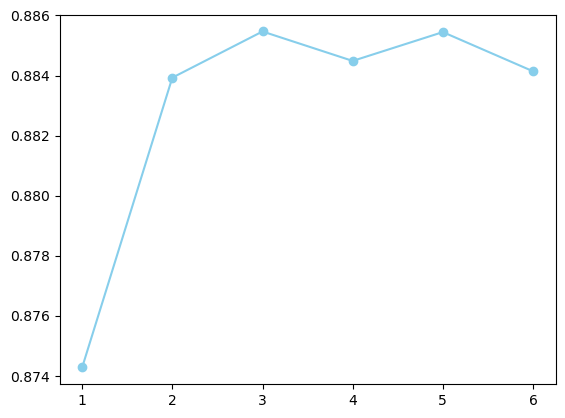

In [161]:
df = pd.DataFrame(results)
plt.plot(df['degree'], df['R2'], marker='o', linestyle='-', color='skyblue')